# Incomplete-Market CVaR Control: Golden Eta Search

This self-contained notebook solves the wealth-only incomplete-market problem

\[
dW_t = \phi_t(\mu\,dt+\sigma\,dB_t)+\beta^\perp dB_t^\perp,
\qquad \phi_t=\varphi_tS_t,
\]

where \(B\) and \(B^\perp\) are independent. It contains only:

- outer bisection for the CVaR multiplier `lambda`, evaluated on an independent randomized holdout sample;
- inner golden-section search for the Rockafellar variable `eta`;
- a one-dimensional finite-difference HJB solver on a 201-node nonuniform wealth grid focused near \(W=-\eta\);
- the same four plotting cells as `Complete_Market_Golden.ipynb`.

Stock price is not an HJB state. It is simulated only for Plot 4.

The HJB policy is fitted on the training Brownian paths, while `lambda` is calibrated on 20,000 separate holdout paths. Plot 3 uses those holdout paths, so its active terminal empirical CVaR satisfies the constraint to the configured numerical tolerance. A wholly unseen future Monte Carlo sample will still have ordinary sampling error.


## 1. Imports


In [ ]:
from __future__ import annotations

from dataclasses import dataclass, replace
import math
import time
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
})


## 2. Wealth-Only Incomplete-Market HJB Solver


In [ ]:
@dataclass
class ModelParams:
    horizon: float = 1.0
    steps: int = 100
    samples: int = 5000
    seed: int = 7

    w0: float = 1.0
    s0: float = 1.0
    r: float = 0.00
    mu: float = 0.08
    sigma: float = 0.20
    mu_t: Optional[tuple[float, ...]] = None
    sigma_t: Optional[tuple[float, ...]] = None
    b: float = 0.0
    beta_perp: float = 0.0
    price_model: str = "gbm"

    gamma: float = 5.0
    alpha: float = 0.95
    cvar_limit: float = -0.70

    phi_min: float = -2.0
    phi_max: float = 2.0

    eta_tol: float = 1.0e-6
    lambda_tol: float = 1.0e-6
    residual_tol: float = 1.0e-6
    eta_max_iter: int = 40
    lambda_max_iter: int = 28
    lambda_initial_high: float = 1.0
    lambda_high_cap: float = 1.0e5

    state_grid_size: int = 201
    state_grid_step: Optional[float] = None
    state_grid_focus_strength: float = 1.0
    state_grid_focus_width: float = 0.20
    hjb_pde_substeps: int = 8
    hjb_cfl_safety: float = 0.20
    hjb_curvature_floor: float = 1.0e-10
    state_grid_padding: float = 0.25
    cap_control_at_merton: bool = True


@dataclass
class ControlResult:
    phi: np.ndarray
    eta: float
    objective: float
    lagrangian: float
    residual: float
    cvar: float
    var: float
    mean_terminal_wealth: float
    terminal_wealth_std: float
    loss_tail_probability: float
    iterations: int
    policy_grid: Optional[np.ndarray] = None
    wealth_grid: Optional[np.ndarray] = None
    terminal_wealth: Optional[np.ndarray] = None
    loss: Optional[np.ndarray] = None
    phi_paths: Optional[np.ndarray] = None
    wealth_paths: Optional[np.ndarray] = None
    stock_paths: Optional[np.ndarray] = None


@dataclass
class CaseResult:
    name: str
    params: ModelParams
    lambda_star: float
    eta_star: float
    objective: float
    cvar: float
    var: float
    residual: float
    terminal_wealth: np.ndarray
    loss: np.ndarray
    phi: np.ndarray
    elapsed_seconds: float
    oracle_calls: int
    mean_terminal_wealth: float
    phi_paths: Optional[np.ndarray] = None
    wealth_paths: Optional[np.ndarray] = None
    stock_paths: Optional[np.ndarray] = None
    policy_grid: Optional[np.ndarray] = None
    wealth_grid: Optional[np.ndarray] = None


def _time_schedule(
    schedule: Optional[tuple[float, ...]], fallback: float, steps: int, name: str
) -> np.ndarray:
    if schedule is None:
        return np.full(steps, float(fallback), dtype=float)
    values = np.asarray(schedule, dtype=float).reshape(-1)
    if values.size == steps + 1:
        values = values[:-1]
    if values.size != steps:
        raise ValueError(
            f"{name} must have length steps or steps + 1; got {values.size} for steps={steps}."
        )
    return values.astype(float, copy=True)


def mu_schedule(params: ModelParams, steps: Optional[int] = None) -> np.ndarray:
    return _time_schedule(params.mu_t, params.mu, params.steps if steps is None else steps, "mu_t")


def sigma_schedule(params: ModelParams, steps: Optional[int] = None) -> np.ndarray:
    return _time_schedule(
        params.sigma_t, params.sigma, params.steps if steps is None else steps, "sigma_t"
    )


def merton_exposure(params: ModelParams) -> np.ndarray:
    mu_t = mu_schedule(params)
    sigma_t = sigma_schedule(params)
    return mu_t / np.maximum(params.gamma * sigma_t**2, 1.0e-12)


def generate_brownian_increments(params: ModelParams) -> np.ndarray:
    rng = np.random.default_rng(params.seed)
    dt = params.horizon / params.steps
    return rng.normal(0.0, math.sqrt(dt), size=(params.samples, params.steps))


def generate_perpendicular_brownian_increments(params: ModelParams) -> np.ndarray:
    """Independent increments for the nontraded wealth shock."""
    rng = np.random.default_rng(params.seed + 1_000_003)
    dt = params.horizon / params.steps
    return rng.normal(0.0, math.sqrt(dt), size=(params.samples, params.steps))


def riskless_growth(params: ModelParams, dt: float) -> float:
    return math.exp(params.r * dt)


def stock_gross_return(
    d_brownian: np.ndarray | float,
    mu_n: float,
    sigma_n: float,
    dt: float,
    params: ModelParams,
) -> np.ndarray | float:
    """One-period stock gross return under the selected price model."""
    d_b = np.asarray(d_brownian)
    if params.price_model == "gbm":
        return np.exp((params.r + mu_n - 0.5 * sigma_n**2) * dt + sigma_n * d_b)
    if params.price_model == "euler":
        return riskless_growth(params, dt) + mu_n * dt + sigma_n * d_b
    raise ValueError(f"Unknown price_model={params.price_model!r}")


def stock_excess_return(
    d_brownian: np.ndarray | float,
    mu_n: float,
    sigma_n: float,
    dt: float,
    params: ModelParams,
) -> np.ndarray | float:
    return stock_gross_return(d_brownian, mu_n, sigma_n, dt, params) - riskless_growth(
        params, dt
    )


def simulate_wealth(phi: np.ndarray, d_brownian: np.ndarray, params: ModelParams) -> np.ndarray:
    samples, steps = d_brownian.shape
    dt = params.horizon / steps
    growth = riskless_growth(params, dt)
    mu_t = mu_schedule(params, steps)
    sigma_t = sigma_schedule(params, steps)
    d_brownian_perp = generate_perpendicular_brownian_increments(
        replace(params, samples=samples, steps=steps)
    )

    wealth = np.empty((samples, steps + 1))
    wealth[:, 0] = params.w0
    for n in range(steps):
        d_b = d_brownian[:, n]
        risky_excess = stock_excess_return(d_b, mu_t[n], sigma_t[n], dt, params)
        wealth[:, n + 1] = (
            growth * wealth[:, n] + phi[n] * risky_excess + params.b * dt + params.beta_perp * d_brownian_perp[:, n]
        )
    return wealth


def cvar_from_loss(loss: np.ndarray, alpha: float) -> tuple[float, float]:
    var = float(np.quantile(loss, alpha))
    cvar = float(var + np.maximum(loss - var, 0.0).mean() / (1.0 - alpha))
    return cvar, var


def lower_tail_wealth_cvar_path(wealth_paths: np.ndarray, alpha: float) -> np.ndarray:
    return np.array([-cvar_from_loss(-wealth_paths[:, n], alpha)[0] for n in range(wealth_paths.shape[1])])


def running_cost(action: np.ndarray | float, params: ModelParams, n: Optional[int] = None) -> np.ndarray | float:
    action_arr = np.asarray(action)
    if n is None:
        if action_arr.ndim > 0 and action_arr.shape[-1] == params.steps:
            shape = (1,) * (action_arr.ndim - 1) + (params.steps,)
            mu_t = mu_schedule(params).reshape(shape)
            sigma_t = sigma_schedule(params).reshape(shape)
            return 0.5 * params.gamma * (sigma_t * action_arr) ** 2 - mu_t * action_arr
        return 0.5 * params.gamma * (params.sigma * action_arr) ** 2 - params.mu * action_arr

    mu_n = mu_schedule(params)[n]
    sigma_n = sigma_schedule(params)[n]
    return 0.5 * params.gamma * (sigma_n * action_arr) ** 2 - mu_n * action_arr


def build_state_grid(
    d_brownian: np.ndarray,
    params: ModelParams,
    focus: Optional[float] = None,
) -> np.ndarray:
    """Adaptive one-dimensional wealth grid, focused near the CVaR kink."""
    merton_probe = np.clip(merton_exposure(params), params.phi_min, params.phi_max)
    probes = [
        np.full(params.steps, params.phi_min),
        merton_probe,
        np.zeros(params.steps),
    ]
    wealth_paths = [simulate_wealth(phi, d_brownian, params) for phi in probes]
    wealth = np.concatenate([path.reshape(-1) for path in wealth_paths])
    low = float(np.quantile(wealth, 0.002))
    high = float(np.quantile(wealth, 0.998))
    width = max(high - low, 1.0e-3)
    low -= params.state_grid_padding * width
    high += params.state_grid_padding * width
    if params.state_grid_step is not None and params.state_grid_step > 0.0:
        step = float(params.state_grid_step)
        grid_low = step * math.floor(low / step)
        grid_high = step * math.ceil(high / step)
        return np.arange(grid_low, grid_high + 0.5 * step, step)

    if (
        focus is None
        or not low < float(focus) < high
        or params.state_grid_focus_strength <= 0.0
        or params.state_grid_focus_width <= 0.0
    ):
        return np.linspace(low, high, params.state_grid_size)

    dense_size = max(4001, 40 * params.state_grid_size + 1)
    dense_grid = np.linspace(low, high, dense_size)
    focus_value = float(focus)
    width_value = float(params.state_grid_focus_width)
    strength_value = float(params.state_grid_focus_strength)
    scaled_distance = (dense_grid - focus_value) / width_value
    density = 1.0 + strength_value * np.exp(-0.5 * scaled_distance**2)
    cell_mass = 0.5 * (density[1:] + density[:-1]) * np.diff(dense_grid)
    cumulative_mass = np.concatenate(([0.0], np.cumsum(cell_mass)))
    total_mass = float(cumulative_mass[-1])
    focus_mass = float(np.interp(focus_value, dense_grid, cumulative_mass))

    interval_count = params.state_grid_size - 1
    left_intervals = int(round(interval_count * focus_mass / total_mass))
    left_intervals = int(np.clip(left_intervals, 1, interval_count - 1))
    right_intervals = interval_count - left_intervals
    left_targets = np.linspace(0.0, focus_mass, left_intervals + 1)
    right_targets = np.linspace(focus_mass, total_mass, right_intervals + 1)[1:]
    target_mass = np.concatenate((left_targets, right_targets))
    return np.interp(target_mass, cumulative_mass, dense_grid)


def simulate_stock_paths(d_brownian: np.ndarray, params: ModelParams) -> np.ndarray:
    """Simulate stock paths on the same Brownian increments as wealth."""
    samples, steps = d_brownian.shape
    dt = params.horizon / steps
    mu_t = mu_schedule(params, steps)
    sigma_t = sigma_schedule(params, steps)
    stock = np.empty((samples, steps + 1))
    stock[:, 0] = params.s0
    for n in range(steps):
        gross_return = stock_gross_return(
            d_brownian[:, n], mu_t[n], sigma_t[n], dt, params
        )
        stock[:, n + 1] = stock[:, n] * gross_return
    return stock



def fit_hjb_policy(
    lambda_value: float,
    eta: float,
    d_brownian: np.ndarray,
    params: ModelParams,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """One-dimensional finite-difference HJB on wealth for fixed (lambda, eta)."""
    wealth_focus = -float(eta) if lambda_value > 0.0 else None
    wealth_grid = build_state_grid(d_brownian, params, focus=wealth_focus)

    dt = params.horizon / params.steps
    mu_t = mu_schedule(params)
    sigma_t = sigma_schedule(params)
    merton_t = merton_exposure(params)
    terminal_penalty = (
        lambda_value
        * np.maximum(-wealth_grid - eta, 0.0)
        / (1.0 - params.alpha)
    )
    value_next = terminal_penalty.copy()

    wealth_size = wealth_grid.size
    value_grid = np.empty((params.steps + 1, wealth_size))
    value_grid[-1] = value_next
    policy_grid = np.empty((params.steps, wealth_size))
    edge_order = 2 if wealth_size >= 3 else 1

    def action_upper(n: int) -> float:
        upper = float(params.phi_max)
        if params.cap_control_at_merton:
            upper = min(upper, float(merton_t[n]))
        return max(float(params.phi_min), upper)

    def derivatives(value: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        value_w = np.gradient(value, wealth_grid, edge_order=edge_order)
        value_ww = np.gradient(value_w, wealth_grid, edge_order=edge_order)
        return value_w, value_ww

    def hamiltonian(
        action: np.ndarray,
        mu_n: float,
        sigma_n: float,
        value_w: np.ndarray,
        value_ww: np.ndarray,
    ) -> np.ndarray:
        wealth_variance = (sigma_n * action) ** 2 + params.beta_perp**2
        return (
            0.5 * params.gamma * (sigma_n * action) ** 2
            - mu_n * action
            + (params.r * wealth_grid + params.b + mu_n * action) * value_w
            + 0.5 * wealth_variance * value_ww
        )

    def minimize_hamiltonian(value: np.ndarray, n: int):
        value_w, value_ww = derivatives(value)
        mu_n = float(mu_t[n])
        sigma_n = float(sigma_t[n])
        upper_n = action_upper(n)

        quadratic = sigma_n**2 * (params.gamma + value_ww)
        linear = mu_n * (value_w - 1.0)
        convex = quadratic > params.hjb_curvature_floor
        interior = np.where(convex, -linear / np.maximum(quadratic, 1.0e-14), 0.0)
        interior = np.clip(interior, params.phi_min, upper_n)

        best_action = interior
        best_value = hamiltonian(interior, mu_n, sigma_n, value_w, value_ww)
        lower_action = np.full_like(interior, params.phi_min)
        upper_action = np.full_like(interior, upper_n)
        lower_value = hamiltonian(lower_action, mu_n, sigma_n, value_w, value_ww)
        upper_value = hamiltonian(upper_action, mu_n, sigma_n, value_w, value_ww)
        use_lower = lower_value < best_value
        best_action = np.where(use_lower, lower_action, best_action)
        best_value = np.where(use_lower, lower_value, best_value)
        use_upper = upper_value < best_value
        best_action = np.where(use_upper, upper_action, best_action)
        best_value = np.where(use_upper, upper_value, best_value)
        return best_action, best_value

    def stable_substeps(n: int) -> int:
        wealth_spacing = float(np.min(np.diff(wealth_grid)))
        sigma_n = abs(float(sigma_t[n]))
        maximum_action = max(abs(params.phi_min), abs(action_upper(n)))
        wealth_variance = (sigma_n * maximum_action) ** 2 + params.beta_perp**2
        diffusion_rate = wealth_variance / max(wealth_spacing**2, 1.0e-14)
        cfl_substeps = int(
            math.ceil(dt * diffusion_rate / max(params.hjb_cfl_safety, 1.0e-6))
        )
        return max(params.hjb_pde_substeps, cfl_substeps, 1)

    for n in range(params.steps - 1, -1, -1):
        value = value_next
        substeps = stable_substeps(n)
        sub_dt = dt / substeps
        best_action = np.zeros(wealth_size)
        for _ in range(substeps):
            best_action, minimized_generator = minimize_hamiltonian(value, n)
            value = value + sub_dt * minimized_generator
            if not np.all(np.isfinite(value)):
                raise FloatingPointError(
                    "The explicit one-dimensional HJB step became unstable. "
                    "Reduce hjb_cfl_safety or increase hjb_pde_substeps."
                )

        value_next = value
        value_grid[n] = value_next
        policy_grid[n] = best_action

    return wealth_grid, policy_grid, value_grid




def simulate_feedback_policy(
    wealth_grid: np.ndarray,
    policy_grid: np.ndarray,
    d_brownian: np.ndarray,
    params: ModelParams,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Simulate the one-dimensional feedback policy phi_n = f_n(W_n)."""
    samples, steps = d_brownian.shape
    dt = params.horizon / steps
    growth = riskless_growth(params, dt)
    mu_t = mu_schedule(params, steps)
    sigma_t = sigma_schedule(params, steps)
    merton_t = merton_exposure(replace(params, steps=steps))
    d_brownian_perp = generate_perpendicular_brownian_increments(
        replace(params, samples=samples, steps=steps)
    )

    wealth = np.empty((samples, steps + 1))
    stock = np.empty((samples, steps + 1))
    phi_paths = np.empty((samples, steps))
    wealth[:, 0] = params.w0
    stock[:, 0] = params.s0

    for n in range(steps):
        phi_n = np.interp(
            wealth[:, n],
            wealth_grid,
            policy_grid[n],
            left=policy_grid[n, 0],
            right=policy_grid[n, -1],
        )
        upper_n = params.phi_max
        if params.cap_control_at_merton:
            upper_n = min(upper_n, float(merton_t[n]))
        phi_n = np.clip(phi_n, params.phi_min, upper_n)
        phi_paths[:, n] = phi_n

        d_b = d_brownian[:, n]
        risky_excess = stock_excess_return(d_b, mu_t[n], sigma_t[n], dt, params)
        gross_return = stock_gross_return(d_b, mu_t[n], sigma_t[n], dt, params)
        wealth[:, n + 1] = (
            growth * wealth[:, n]
            + phi_n * risky_excess
            + params.b * dt
            + params.beta_perp * d_brownian_perp[:, n]
        )
        stock[:, n + 1] = stock[:, n] * gross_return

    return wealth, stock, phi_paths


def feedback_value_iteration_kernel(
    lambda_value: float,
    eta: float,
    d_brownian: np.ndarray,
    params: ModelParams,
) -> ControlResult:
    wealth_grid, policy_grid, _ = fit_hjb_policy(
        lambda_value, eta, d_brownian, params
    )
    wealth, stock, phi_paths = simulate_feedback_policy(
        wealth_grid, policy_grid, d_brownian, params
    )

    dt = params.horizon / params.steps
    terminal_wealth = wealth[:, -1]
    loss = -terminal_wealth
    hinge = np.maximum(loss - eta, 0.0)
    running = dt * np.sum(running_cost(phi_paths, params), axis=1)
    objective = float(np.mean(running))
    residual = float(
        eta + hinge.mean() / (1.0 - params.alpha) - params.cvar_limit
    )
    lagrangian = objective + lambda_value * residual
    cvar, var = cvar_from_loss(loss, params.alpha)

    return ControlResult(
        phi=np.mean(phi_paths, axis=0),
        eta=eta,
        objective=objective,
        lagrangian=lagrangian,
        residual=residual,
        cvar=cvar,
        var=var,
        mean_terminal_wealth=float(np.mean(terminal_wealth)),
        terminal_wealth_std=float(np.std(terminal_wealth)),
        loss_tail_probability=float(np.mean(loss > eta)),
        iterations=params.steps,
        policy_grid=policy_grid,
        wealth_grid=wealth_grid,
        terminal_wealth=terminal_wealth,
        loss=loss,
        phi_paths=phi_paths,
        wealth_paths=wealth,
        stock_paths=stock,
    )



def unconstrained_solution(d_brownian: np.ndarray, params: ModelParams) -> ControlResult:
    result = feedback_value_iteration_kernel(0.0, 0.0, d_brownian, params)
    loss = result.loss if result.loss is not None else -result.terminal_wealth
    cvar, var = cvar_from_loss(loss, params.alpha)
    return replace(
        result,
        eta=var,
        residual=cvar - params.cvar_limit,
        cvar=cvar,
        var=var,
        loss_tail_probability=float(np.mean(loss > var)),
        loss=loss,
    )


def eta_bracket(params: ModelParams) -> tuple[float, float]:
    mu_abs_max = float(np.max(np.abs(mu_schedule(params))))
    sigma_abs_max = float(np.max(np.abs(sigma_schedule(params))))
    max_exposure = max(abs(params.phi_min), abs(params.phi_max))
    drift_bound = abs(params.w0) + params.horizon * (
        abs(params.r) * (abs(params.w0) + 4.0) + mu_abs_max * max_exposure + abs(params.b)
    )
    diffusion_bound = 6.0 * math.sqrt(params.horizon) * (sigma_abs_max * max_exposure + abs(params.beta_perp))
    return -max(2.0, drift_bound + diffusion_bound), max(2.0, drift_bound + diffusion_bound)


def eta_golden_search(lambda_value: float, d_brownian: np.ndarray, params: ModelParams) -> ControlResult:
    """Golden-section search for eta using |eta - empirical VaR_alpha(loss)|.

    The fixed-point form is numerically stable on the nonuniform HJB grid and
    is equivalent to the Rockafellar eta condition at the solution.
    """
    if lambda_value <= 0.0:
        return unconstrained_solution(d_brownian, params)

    eta_low, eta_high = eta_bracket(params)
    rho = (math.sqrt(5.0) - 1.0) / 2.0

    eta1 = eta_high - rho * (eta_high - eta_low)
    eta2 = eta_low + rho * (eta_high - eta_low)
    result1 = feedback_value_iteration_kernel(lambda_value, eta1, d_brownian, params)
    result2 = feedback_value_iteration_kernel(lambda_value, eta2, d_brownian, params)

    def eta_score(result: ControlResult) -> float:
        loss = result.loss if result.loss is not None else -result.terminal_wealth
        empirical_var = float(np.quantile(loss, params.alpha))
        return abs(float(result.eta) - empirical_var)

    best = min(
        (result1, result2),
        key=lambda result: (eta_score(result), result.lagrangian),
    )

    for _ in range(max(params.eta_max_iter - 1, 0)):
        if eta_score(result1) <= eta_score(result2):
            eta_high = eta2
            eta2 = eta1
            result2 = result1
            eta1 = eta_high - rho * (eta_high - eta_low)
            result1 = feedback_value_iteration_kernel(lambda_value, eta1, d_brownian, params)
        else:
            eta_low = eta1
            eta1 = eta2
            result1 = result2
            eta2 = eta_low + rho * (eta_high - eta_low)
            result2 = feedback_value_iteration_kernel(lambda_value, eta2, d_brownian, params)
        best = min(
            (best, result1, result2),
            key=lambda result: (eta_score(result), result.lagrangian),
        )
        if eta_high - eta_low <= params.eta_tol:
            break

    return best


def _history_row(lambda_value: float, result: ControlResult) -> dict[str, float]:
    return {
        "lambda": float(lambda_value),
        "eta": float(result.eta),
        "residual": float(result.residual),
        "objective": float(result.objective),
        "cvar": float(result.cvar),
    }



def evaluate_policy_on_holdout(
    trained_result: ControlResult,
    lambda_value: float,
    d_brownian_holdout: np.ndarray,
    holdout_params: ModelParams,
) -> ControlResult:
    """Evaluate a trained HJB policy on an independent holdout sample."""
    wealth, stock, phi_paths = simulate_feedback_policy(
        trained_result.wealth_grid,
        trained_result.policy_grid,
        d_brownian_holdout,
        holdout_params,
    )
    terminal_wealth = wealth[:, -1]
    loss = -terminal_wealth
    hinge = np.maximum(loss - trained_result.eta, 0.0)
    rockafellar_residual = float(
        trained_result.eta
        + hinge.mean() / (1.0 - holdout_params.alpha)
        - holdout_params.cvar_limit
    )
    cvar, var = cvar_from_loss(loss, holdout_params.alpha)
    return replace(
        trained_result,
        phi=np.mean(phi_paths, axis=0),
        lagrangian=(
            trained_result.objective
            + lambda_value * rockafellar_residual
        ),
        residual=rockafellar_residual,
        cvar=cvar,
        var=var,
        mean_terminal_wealth=float(np.mean(terminal_wealth)),
        terminal_wealth_std=float(np.std(terminal_wealth)),
        loss_tail_probability=float(
            np.mean(loss > trained_result.eta)
        ),
        terminal_wealth=terminal_wealth,
        loss=loss,
        phi_paths=phi_paths,
        wealth_paths=wealth,
        stock_paths=stock,
    )


def constraint_residual(result: ControlResult, params: ModelParams) -> float:
    """Independent holdout loss-CVaR residual for lambda bisection."""
    return float(result.cvar - params.cvar_limit)


def outer_bisection(
    d_brownian: np.ndarray,
    params: ModelParams,
    d_brownian_holdout: np.ndarray,
    holdout_params: ModelParams,
) -> tuple[ControlResult, float, list[dict[str, float]]]:
    """Fit on training paths and bisect lambda on holdout CVaR."""
    history: list[dict[str, float]] = []

    def fit_and_evaluate(lambda_value: float) -> ControlResult:
        trained = eta_golden_search(lambda_value, d_brownian, params)
        return evaluate_policy_on_holdout(
            trained,
            lambda_value,
            d_brownian_holdout,
            holdout_params,
        )

    unconstrained = fit_and_evaluate(0.0)
    history.append(_history_row(0.0, unconstrained))
    target_tol = params.residual_tol
    unconstrained_residual = constraint_residual(unconstrained, params)
    if unconstrained_residual <= 0.0:
        return unconstrained, 0.0, history

    lambda_low = 0.0
    lambda_high = params.lambda_initial_high
    high_result = fit_and_evaluate(lambda_high)
    history.append(_history_row(lambda_high, high_result))

    while constraint_residual(high_result, params) > 0.0:
        lambda_low = lambda_high
        lambda_high *= 2.0
        if lambda_high > params.lambda_high_cap:
            raise RuntimeError(
                "Failed to bracket a feasible holdout multiplier."
            )
        high_result = fit_and_evaluate(lambda_high)
        history.append(_history_row(lambda_high, high_result))

    best_result = min(
        (unconstrained, high_result),
        key=lambda result: abs(constraint_residual(result, params)),
    )
    best_lambda = (
        0.0 if best_result is unconstrained else lambda_high
    )
    for _ in range(params.lambda_max_iter):
        lambda_mid = 0.5 * (lambda_low + lambda_high)
        mid_result = fit_and_evaluate(lambda_mid)
        history.append(_history_row(lambda_mid, mid_result))
        mid_residual = constraint_residual(mid_result, params)
        if abs(mid_residual) < abs(
            constraint_residual(best_result, params)
        ):
            best_result = mid_result
            best_lambda = lambda_mid
        if abs(mid_residual) <= target_tol:
            return mid_result, lambda_mid, history
        if mid_residual > 0.0:
            lambda_low = lambda_mid
        else:
            lambda_high = lambda_mid
        if lambda_high - lambda_low <= params.lambda_tol:
            break

    return best_result, best_lambda, history


def solve_case(
    name: str,
    params: ModelParams,
    holdout_seed: int,
    holdout_samples: int,
) -> CaseResult:
    started = time.perf_counter()
    d_brownian = generate_brownian_increments(params)
    holdout_params = replace(
        params,
        samples=int(holdout_samples),
        seed=int(holdout_seed),
    )
    d_brownian_holdout = generate_brownian_increments(holdout_params)
    result, lambda_star, history = outer_bisection(
        d_brownian,
        params,
        d_brownian_holdout,
        holdout_params,
    )
    terminal_wealth = result.terminal_wealth
    loss = result.loss if result.loss is not None else -terminal_wealth
    cvar, var = cvar_from_loss(loss, params.alpha)
    return CaseResult(
        name=name,
        params=params,
        lambda_star=lambda_star,
        eta_star=result.eta,
        objective=result.objective,
        cvar=cvar,
        var=var,
        residual=cvar - params.cvar_limit,
        terminal_wealth=terminal_wealth,
        loss=loss,
        phi=result.phi,
        elapsed_seconds=time.perf_counter() - started,
        oracle_calls=len(history),
        mean_terminal_wealth=float(np.mean(terminal_wealth)),
        phi_paths=result.phi_paths,
        wealth_paths=result.wealth_paths,
        policy_grid=result.policy_grid,
        wealth_grid=result.wealth_grid,
        stock_paths=result.stock_paths,
    )


def summarize_case(case: CaseResult) -> dict[str, float | str]:
    phi_values = case.phi_paths if case.phi_paths is not None else case.phi[None, :]
    return {
        "case": case.name,
        "lambda*": case.lambda_star,
        "E[W_T]": float(np.mean(case.terminal_wealth)),
        "std(W_T)": float(np.std(case.terminal_wealth)),
        "wealth tail CVaR": -case.cvar,
        "floor -c": -case.params.cvar_limit,
        "slack c-CVaR": case.params.cvar_limit - case.cvar,
        "mean phi=varphi*S": float(np.mean(phi_values)),
        "min phi": float(np.min(phi_values)),
        "max phi": float(np.max(phi_values)),
        "runtime sec": case.elapsed_seconds,
    }


def print_summary_table(cases: list[CaseResult]) -> None:
    rows = [summarize_case(case) for case in cases]
    headers = ["case", "lambda*", "E[W_T]", "wealth tail CVaR", "floor -c", "mean phi=varphi*S", "runtime sec"]
    print(" | ".join(headers))
    print(" | ".join("-" * len(h) for h in headers))
    for row in rows:
        values = []
        for header in headers:
            value = row[header]
            values.append(f"{value:.4f}" if isinstance(value, float) else str(value))
        print(" | ".join(values))

## 3. Settings


In [ ]:
BASE_PARAMS = ModelParams(
    horizon=1.0,
    steps=100,
    samples=5000,
    seed=7,
    w0=1.0,
    s0=1.0,
    r=0.0,
    mu=0.08,
    sigma=0.20,
    b=0.0,
    beta_perp=0.02,
    price_model="gbm",
    gamma=5.0,
    alpha=0.95,
    phi_min=-2.0,
    phi_max=2.0,
    cvar_limit=-0.86,
    eta_tol=5.0e-4,
    lambda_tol=1.0e-6,
    residual_tol=1.0e-5,
    eta_max_iter=40,
    lambda_max_iter=20,
    lambda_initial_high=1.0,
    lambda_high_cap=1.0e5,
    state_grid_size=201,
    state_grid_step=None,
    state_grid_focus_strength=1.0,
    state_grid_focus_width=0.20,
    state_grid_padding=0.25,
    hjb_pde_substeps=8,
    hjb_cfl_safety=0.20,
    hjb_curvature_floor=1.0e-10,
    cap_control_at_merton=True,
)

CASE_PARAMS = {
    "inactive": replace(BASE_PARAMS, cvar_limit=-0.86, seed=11),
    "active": replace(BASE_PARAMS, cvar_limit=-0.94, seed=13),
}

HOLDOUT_SAMPLES = 20000
HOLDOUT_SEED = 686035552
# int(np.random.SeedSequence().generate_state(1)[0])
print(
    f"randomized holdout: seed={HOLDOUT_SEED}, "
    f"paths={HOLDOUT_SAMPLES}"
)

time_grid = np.linspace(
    0.0, BASE_PARAMS.horizon, BASE_PARAMS.steps + 1
)
merton_line = merton_exposure(BASE_PARAMS)

print("searches: outer lambda bisection, inner eta golden section")
print(
    "HJB state: wealth only, "
    f"{BASE_PARAMS.state_grid_size} nonuniform points"
)
print(
    "wealth-grid focus: W=-eta, "
    f"width={BASE_PARAMS.state_grid_focus_width:.2f}"
)
print(
    f"time steps: {BASE_PARAMS.steps}, paths: {BASE_PARAMS.samples}"
)
print(
    f"r={BASE_PARAMS.r:.4f}, beta_perp={BASE_PARAMS.beta_perp:.4f}, "
    f"Merton exposure={merton_line[0]:.4f}"
)


randomized holdout: seed=686035552, paths=20000
searches: outer lambda bisection, inner eta golden section
HJB state: wealth only, 201 nonuniform points
wealth-grid focus: W=-eta, width=0.20
time steps: 100, paths: 5000
r=0.0000, beta_perp=0.0200, Merton exposure=0.4000


## 4. Run Active And Inactive Cases


In [ ]:
cases = [
    solve_case(
        "inactive",
        CASE_PARAMS["inactive"],
        HOLDOUT_SEED,
        HOLDOUT_SAMPLES,
    ),
    solve_case(
        "active",
        CASE_PARAMS["active"],
        HOLDOUT_SEED,
        HOLDOUT_SAMPLES,
    ),
]

print_summary_table(cases)

active_case = next(case for case in cases if case.name == "active")
print(f"active eta*: {active_case.eta_star:.9f}")
print(f"active wealth-tail CVaR: {-active_case.cvar:.9f}")
print(f"active empirical residual: {active_case.residual:+.3e}")


case | lambda* | E[W_T] | wealth tail CVaR | floor -c | mean phi=varphi*S | runtime sec
---- | ------- | ------ | ---------------- | -------- | ----------------- | -----------
inactive | 0.0000 | 1.0317 | 0.8642 | 0.8600 | 0.4000 | 8.0951
active | 0.1306 | 1.0205 | 0.9400 | 0.9400 | 0.2601 | 2135.4206
active eta*: -0.949854375
active wealth-tail CVaR: 0.940045775
active empirical residual: -4.577e-05


## 5. Shared Plot Helpers


In [ ]:
CASE_COLORS = {
    "inactive": "#2563eb",
    "active": "#dc2626",
}
CASE_LABELS = {
    "inactive": "inactive",
    "active": "active",
}


def gaussian_kde_1d(samples, grid, bandwidth=None):
    samples = np.asarray(samples, dtype=float)
    if bandwidth is None:
        scale = max(float(np.std(samples, ddof=1)), 1.0e-8)
        bandwidth = max(
            1.06 * scale * samples.size ** (-0.2),
            1.0e-4,
        )
    z = (grid[:, None] - samples[None, :]) / bandwidth
    return np.exp(-0.5 * z * z).mean(axis=1) / (
        bandwidth * np.sqrt(2.0 * np.pi)
    )


def simulate_case_paths(case, path_count, seed_shift):
    params = replace(
        case.params,
        samples=path_count,
        seed=case.params.seed + seed_shift,
    )
    d_brownian = generate_brownian_increments(params)
    return simulate_feedback_policy(
        case.wealth_grid,
        case.policy_grid,
        d_brownian,
        params,
    )


## Plot 1. Terminal Wealth Distribution


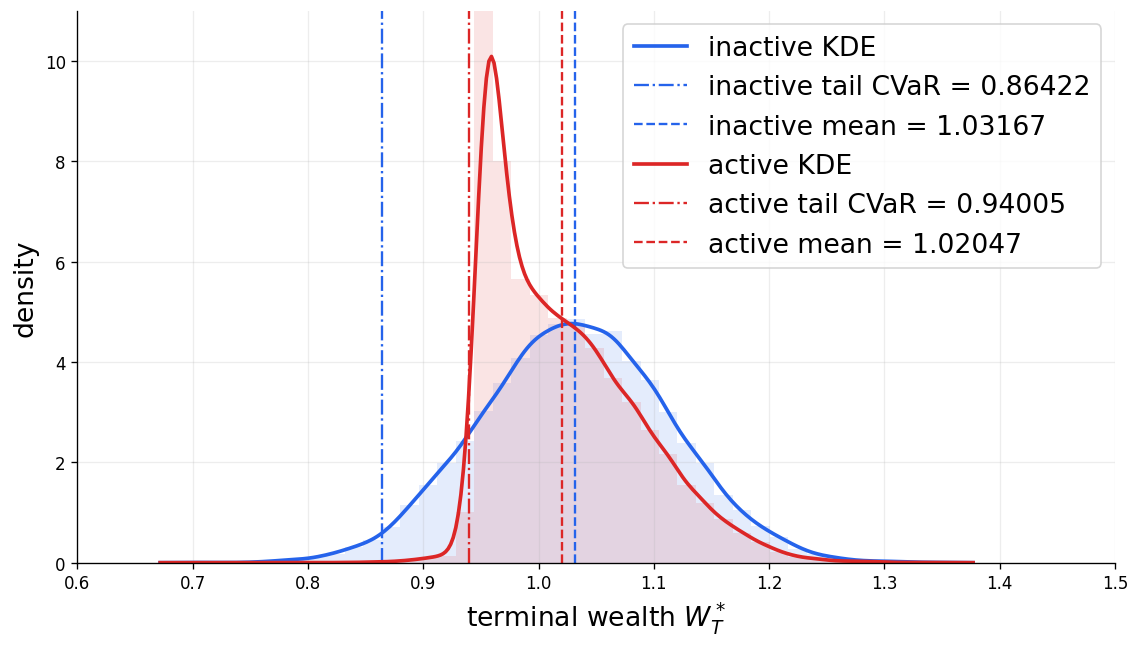

In [ ]:
def plot_terminal_wealth_distribution(
    cases,
    bins_count=44,
    figsize=(9.6, 5.5),
    save_path=None,
):
    all_wealth = np.concatenate(
        [case.terminal_wealth for case in cases]
    )
    padding = 0.04 * max(float(np.ptp(all_wealth)), 1.0e-3)
    grid = np.linspace(
        all_wealth.min() - padding,
        all_wealth.max() + padding,
        320,
    )
    bins = np.linspace(grid[0], grid[-1], bins_count + 1)
    fig, ax = plt.subplots(figsize=figsize)

    for case in cases:
        color = CASE_COLORS[case.name]
        label = CASE_LABELS[case.name]
        ax.hist(
            case.terminal_wealth,
            bins=bins,
            density=True,
            color=color,
            alpha=0.12,
            edgecolor="none",
        )
        ax.plot(
            grid,
            gaussian_kde_1d(case.terminal_wealth, grid),
            color=color,
            linewidth=2.2,
            label=f"{label} KDE",
        )
        ax.axvline(
            -case.cvar,
            color=color,
            linestyle="-.",
            linewidth=1.4,
            label=f"{label} tail CVaR = {-case.cvar:.5f}",
        )
        terminal_mean = float(np.mean(case.terminal_wealth))
        ax.axvline(
            terminal_mean,
            color=color,
            linestyle="--",
            linewidth=1.4,
            label=f"{label} mean = {terminal_mean:.5f}",
        )

    ax.set_xlabel(r"terminal wealth $W_T^*$", fontsize=16)
    ax.set_xlim(0.6,1.5)
    ax.set_ylim(0.0, 11.0)
    ax.set_ylabel("density", fontsize=16)
    ax.legend(loc="upper right", frameon=True, fontsize=16)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    return fig, ax


fig_terminal, ax_terminal = plot_terminal_wealth_distribution(cases)


## Plot 2. Dollar Risky Exposure


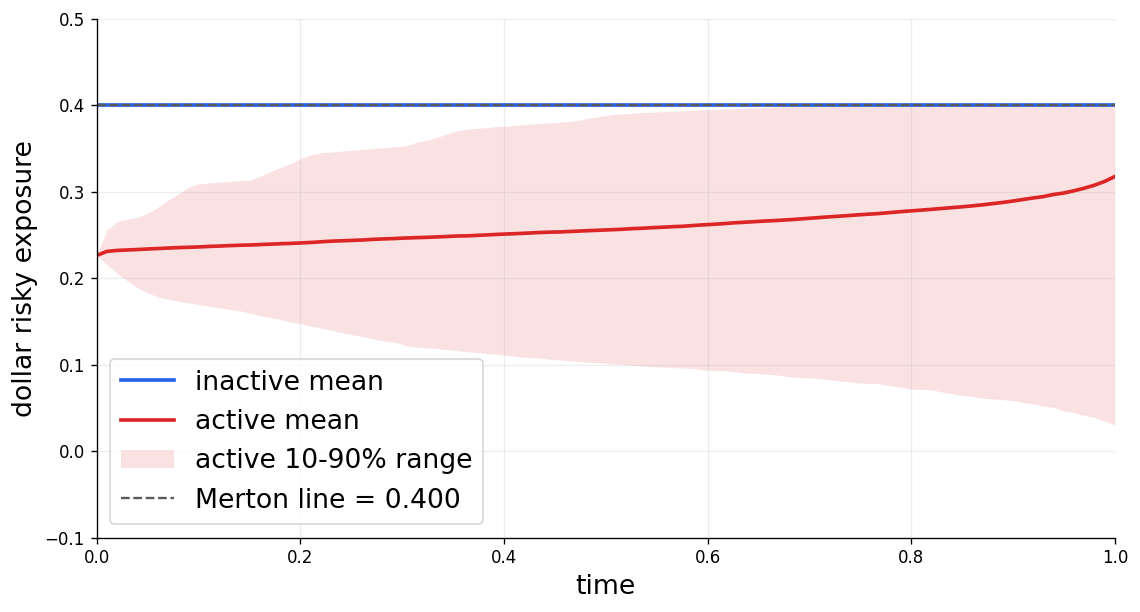

In [ ]:
def plot_exposure_trajectory(
    cases,
    figsize=(9.6, 5.2),
    save_path=None,
):
    t = np.linspace(
        0.0, BASE_PARAMS.horizon, BASE_PARAMS.steps
    )
    fig, ax = plt.subplots(figsize=figsize)

    for case in cases:
        color = CASE_COLORS[case.name]
        label = CASE_LABELS[case.name]
        mean_phi = np.mean(case.phi_paths, axis=0)
        ax.plot(
            t,
            mean_phi,
            color=color,
            linewidth=2.2,
            label=f"{label} mean",
        )
        if case.name == "active":
            q10, q90 = np.quantile(
                case.phi_paths, [0.10, 0.90], axis=0
            )
            ax.fill_between(
                t,
                q10,
                q90,
                color=color,
                alpha=0.13,
                linewidth=0,
                label="active 10-90% range",
            )

    ax.axhline(
        float(merton_line[0]),
        color="0.35",
        linestyle="--",
        linewidth=1.4,
        label=f"Merton line = {merton_line[0]:.3f}",
    )
    ax.set_xlim(0.0, BASE_PARAMS.horizon)
    ax.set_ylim(-0.10, 0.50)
    ax.set_xlabel("time", fontsize=16)
    ax.set_ylabel(r"dollar risky exposure", fontsize=16)
    ax.legend(loc="best", frameon=True, fontsize=16)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    return fig, ax


fig_control, ax_control = plot_exposure_trajectory(cases)


## Plot 3. Wealth CVaR Over Time


Plot 3 fresh Monte Carlo seed: 3633020937


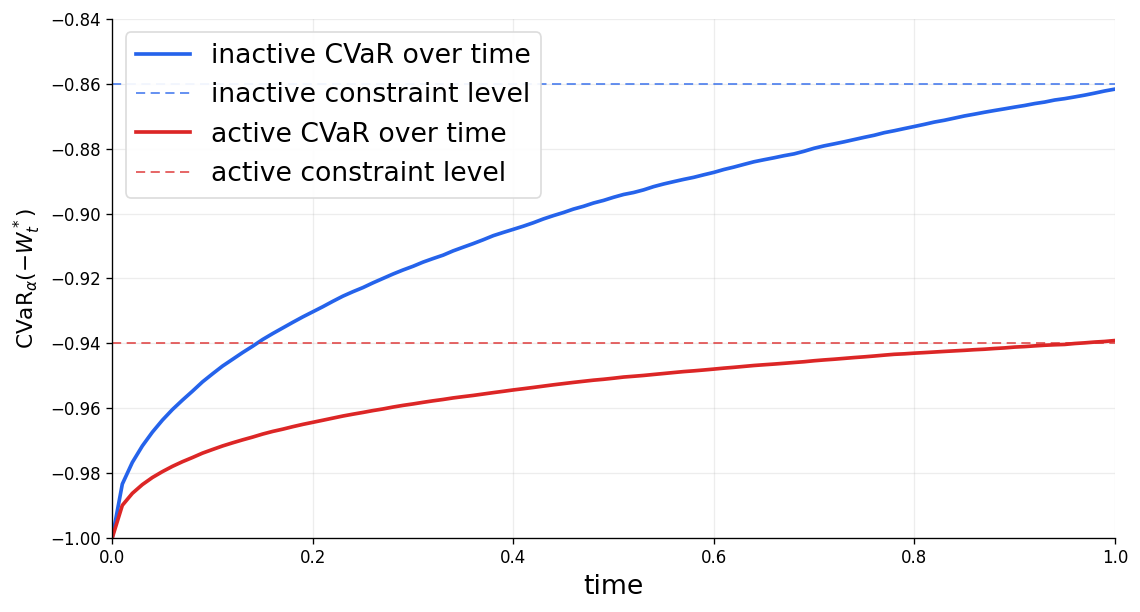

In [ ]:
def resimulate_case_wealth_paths(case, plot_samples=5000, plot_seed=None):
    if plot_seed is None:
        plot_seed = int(np.random.SeedSequence().generate_state(1)[0])
    plot_params = replace(
        case.params,
        samples=plot_samples,
        seed=int(plot_seed),
    )
    d_brownian = generate_brownian_increments(plot_params)
    wealth_paths, _, _ = simulate_feedback_policy(
        case.wealth_grid,
        case.policy_grid,
        d_brownian,
        plot_params,
    )
    return wealth_paths


def plot_wealth_cvar_over_time(
    cases,
    plot_samples=None,
    plot_seed=None,
    terminal_tolerance=2.0e-3,
    figsize=(9.6, 5.2),
    save_path=None,
):
    if plot_samples is not None and plot_seed is None:
        plot_seed = int(np.random.SeedSequence().generate_state(1)[0])
    if plot_samples is not None:
        print(f"Plot 3 fresh Monte Carlo seed: {plot_seed}")

    fig, ax = plt.subplots(figsize=figsize)
    for case in cases:
        color = CASE_COLORS.get(case.name, "black")
        label = CASE_LABELS.get(case.name, case.name)
        if plot_samples is None:
            wealth_paths = case.wealth_paths
        else:
            wealth_paths = resimulate_case_wealth_paths(
                case,
                plot_samples=plot_samples,
                plot_seed=plot_seed,
            )

        wealth_cvar = lower_tail_wealth_cvar_path(
            wealth_paths,
            case.params.alpha,
        )
        plot_terminal_cvar = wealth_cvar[-1]
        solver_terminal_cvar = -case.cvar
        terminal_floor = -case.params.cvar_limit
        terminal_gap = abs(
            plot_terminal_cvar - solver_terminal_cvar
        )
        if terminal_gap > terminal_tolerance:
            print(
                f"warning: {case.name} plot terminal CVaR differs "
                f"from solver by {terminal_gap:.6f}; use "
                "plot_samples=None to plot solver paths exactly."
            )

        t = np.linspace(
            0.0,
            case.params.horizon,
            wealth_cvar.size,
        )
        ax.plot(
            t,
            -wealth_cvar,
            color=color,
            linewidth=2.2,
            label=f"{label} CVaR over time",
        )
        ax.axhline(
            -terminal_floor,
            color=color,
            linewidth=1.1,
            linestyle=(0, (5, 3)),
            alpha=0.75,
            label=f"{label} constraint level",
        )

    ax.set_xlabel("time", fontsize=16)
    ax.set_ylabel(r"CVaR$_\alpha(-W_t^*)$", fontsize=13)
    ax.set_xlim(0.0, BASE_PARAMS.horizon)
    ax.set_ylim(-1.0, -0.84)
    ax.legend(
        loc="best",
        frameon=True,
        framealpha=0.92,
        edgecolor="0.85",
        fontsize=16,
    )
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    return fig, ax


fig_cvar_time, ax_cvar_time = plot_wealth_cvar_over_time(
    cases,
    plot_samples=100000,
)


## Plot 4. Selected Good And Bad Market Paths


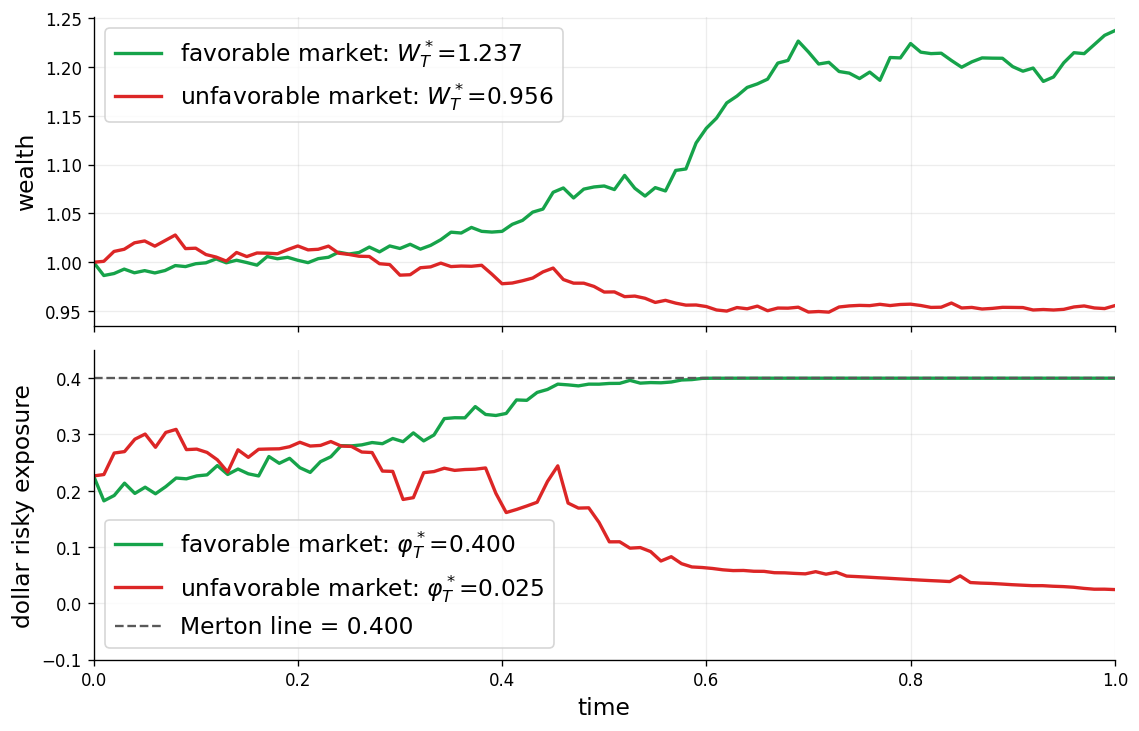

In [ ]:
def select_good_bad_paths(
    stock_paths,
    phi_paths,
    merton_value,
    horizon,
    close_after=0.6,
    not_close_before=0.5,
    close_tolerance=0.01,
):
    """Select favorable/adverse markets using terminal stock quartiles.

    Within the favorable quartile, choose the path whose risky exposure is
    closest to the Merton line on [close_after, T], subject to staying
    at least close_tolerance away from Merton before not_close_before.
    """
    terminal_stock = stock_paths[:, -1]
    control_time = np.linspace(0.0, horizon, phi_paths.shape[1])
    after_cutoff = control_time >= close_after
    before_cutoff = control_time < not_close_before
    if not np.any(after_cutoff):
        raise ValueError("close_after must be smaller than or equal to T.")
    if not np.any(before_cutoff):
        raise ValueError("not_close_before must be greater than zero.")
    absolute_gap = np.abs(phi_paths - merton_value)
    post_merton_gap = np.mean(
        absolute_gap[:, after_cutoff],
        axis=1,
    )
    minimum_early_gap = np.min(
        absolute_gap[:, before_cutoff],
        axis=1,
    )
    post_cutoff_phi = phi_paths[:, after_cutoff].mean(axis=1)

    good_pool = np.where(
        terminal_stock >= np.quantile(terminal_stock, 0.75)
    )[0]
    bad_pool = np.where(
        terminal_stock <= np.quantile(terminal_stock, 0.25)
    )[0]
    delayed_good_pool = good_pool[
        minimum_early_gap[good_pool] >= close_tolerance
    ]
    if delayed_good_pool.size == 0:
        raise RuntimeError(
            "No favorable path stays sufficiently below Merton before "
            f"t={not_close_before:.2f}."
        )
    close_good_pool = delayed_good_pool[
        post_merton_gap[delayed_good_pool] <= close_tolerance
    ]
    if close_good_pool.size == 0:
        close_good_pool = delayed_good_pool
    good_idx = close_good_pool[
        np.argmin(post_merton_gap[close_good_pool])
    ]
    bad_idx = bad_pool[np.argmin(post_cutoff_phi[bad_pool])]
    return int(good_idx), int(bad_idx)


def plot_good_bad_market_paths(
    active_case,
    path_count=8000,
    close_after=0.6,
    not_close_before=0.5,
    close_tolerance=0.01,
    figsize=(9.6, 6.2),
    save_path=None,
):
    wealth, stock, phi_paths = simulate_case_paths(
        active_case,
        path_count=path_count,
        seed_shift=250000,
    )
    merton_value = float(merton_exposure(active_case.params)[-1])
    good_idx, bad_idx = select_good_bad_paths(
        stock,
        phi_paths,
        merton_value,
        horizon=active_case.params.horizon,
        close_after=close_after,
        not_close_before=not_close_before,
        close_tolerance=close_tolerance,
    )
    t_wealth = np.linspace(
        0.0,
        active_case.params.horizon,
        active_case.params.steps + 1,
    )
    t_phi = np.linspace(
        0.0,
        active_case.params.horizon,
        active_case.params.steps,
    )
    after_cutoff = t_phi >= close_after
    fig, (ax_wealth, ax_phi) = plt.subplots(
        2, 1, figsize=figsize, sharex=True
    )

    for index, color, label in [
        (good_idx, "#16a34a", "favorable market"),
        (bad_idx, CASE_COLORS["active"], "unfavorable market"),
    ]:
        post_cutoff_phi = float(
            phi_paths[index, after_cutoff].mean()
        )
        ax_wealth.plot(
            t_wealth,
            wealth[index],
            color=color,
            linewidth=2.0,
            label=f"{label}: $W_T^*$={wealth[index, -1]:.3f}",
        )
        ax_phi.plot(
            t_phi,
            phi_paths[index],
            color=color,
            linewidth=2.0,
            label=(
                fr"{label}: $\varphi_T^*$={phi_paths[index,-1]:.3f}"
            ),
        )

    ax_phi.axhline(
        merton_value,
        color="0.35",
        linestyle="--",
        linewidth=1.4,
        label=f"Merton line = {merton_value:.3f}",
    )
    ax_wealth.set_ylabel(r"wealth", fontsize=14)
    ax_phi.set_ylabel(r"dollar risky exposure", fontsize=14)
    ax_phi.set_xlabel("time", fontsize=14)
    ax_phi.set_xlim(0.0, active_case.params.horizon)
    ax_phi.set_ylim(-0.10, 0.45)
    ax_wealth.legend(loc="upper left", frameon=True, fontsize=14)
    ax_phi.legend(loc="lower left", frameon=True, fontsize=14)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
    return fig, (ax_wealth, ax_phi), (good_idx, bad_idx)


active_case = next(case for case in cases if case.name == "active")
fig_paths, axes_paths, selected_paths = plot_good_bad_market_paths(
    active_case
)


In [ ]:
print("HOLDOUT_SEED =", HOLDOUT_SEED)
# using seed 686035552 to generate the same plot as in the paper

# Plot 4 Brownian-path seed: 13 + 250000 = 250013

HOLDOUT_SEED = 686035552
